In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,confusion_matrix,classification_report

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import os
for dirname,_,filenames in os.walk('/kaggle/input'):
  for filename in filenames:
    print(os.path.join(dirname,filename))

import pickle

#EDA Target=Fraud_indicator

In [58]:
df=pd.read_csv('FastagFraudDetection.csv')

In [59]:
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


In [60]:
df.shape

(5000, 13)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Transaction_ID         5000 non-null   int64 
 1   Timestamp              5000 non-null   object
 2   Vehicle_Type           5000 non-null   object
 3   FastagID               4451 non-null   object
 4   TollBoothID            5000 non-null   object
 5   Lane_Type              5000 non-null   object
 6   Vehicle_Dimensions     5000 non-null   object
 7   Transaction_Amount     5000 non-null   int64 
 8   Amount_paid            5000 non-null   int64 
 9   Geographical_Location  5000 non-null   object
 10  Vehicle_Speed          5000 non-null   int64 
 11  Vehicle_Plate_Number   5000 non-null   object
 12  Fraud_indicator        5000 non-null   object
dtypes: int64(4), object(9)
memory usage: 507.9+ KB


Missing values count

In [62]:
df.describe()

,Transaction_ID,Transaction_Amount,Amount_paid,Vehicle_Speed
count,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,161.06200,141.261000,67.851200
std,1443.520003,112.44995,106.480996,16.597547
min,1.000000,0.00000,0.000000,10.000000
25%,1250.750000,100.00000,90.000000,54.000000
50%,2500.500000,130.00000,120.000000,67.000000
75%,3750.250000,290.00000,160.000000,82.000000
max,5000.000000,350.00000,350.000000,118.000000


In [63]:
#converting timestamp to datetime
df['Timestamp']=pd.to_datetime(df['Timestamp'])

In [64]:
df.isnull().sum()

,0
Transaction_ID,0
Timestamp,0
Vehicle_Type,0
FastagID,549
TollBoothID,0
Lane_Type,0
Vehicle_Dimensions,0
Transaction_Amount,0
Amount_paid,0
Geographical_Location,0


In [65]:
df.dropna(subset=['FastagID'],inplace=True)

In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df.shape

(4451, 13)

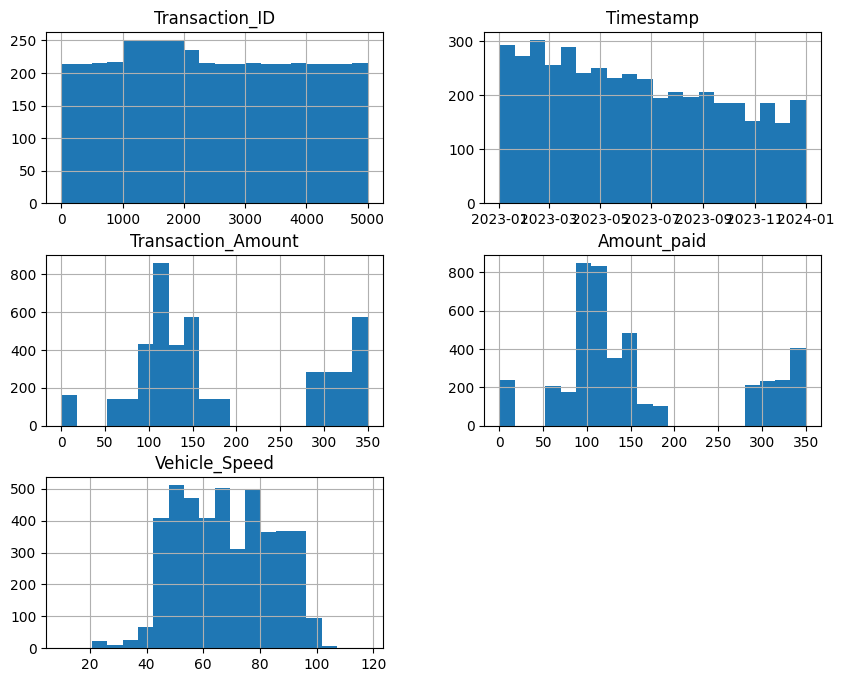

In [68]:
df.hist(figsize=(10,8),bins=20)
plt.show()

/tmp/ipykernel_10469/4118878112.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fraud_indicator',data=df,palette='coolwarm')


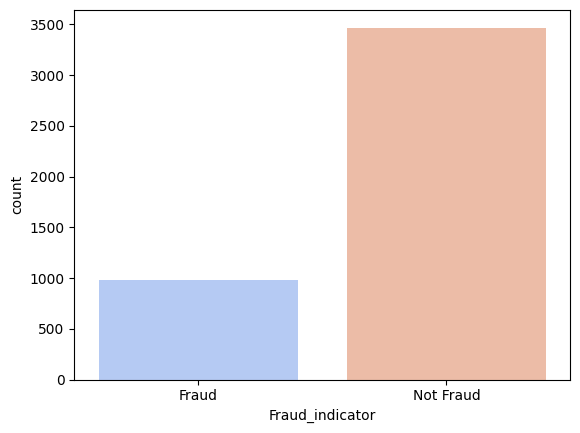

In [69]:
sns.countplot(x='Fraud_indicator',data=df,palette='coolwarm')
plt.show()

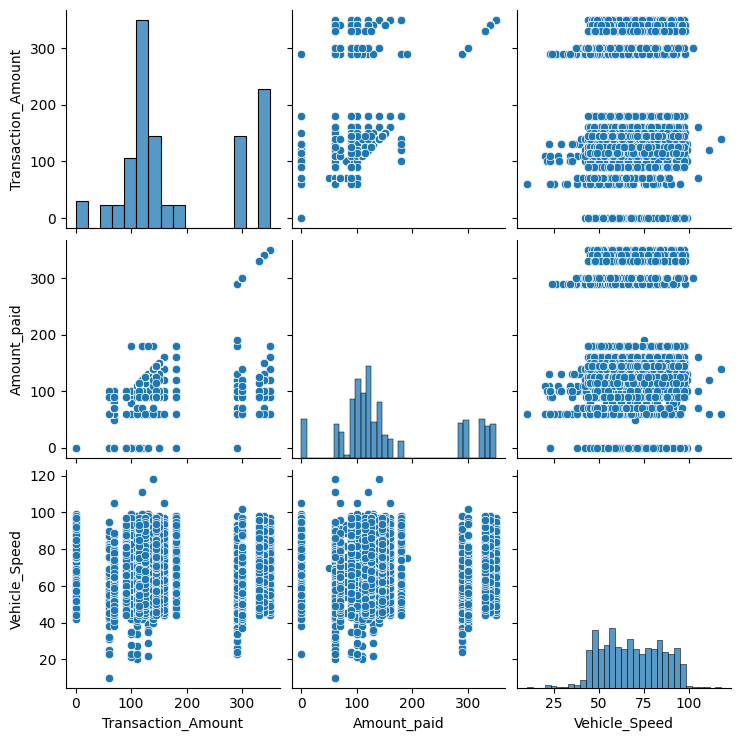

In [70]:
sns.pairplot(df,vars=['Transaction_Amount','Amount_paid','Vehicle_Speed'])
plt.show()

/tmp/ipykernel_10469/3829783051.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fraud_indicator',y='Transaction_Amount',data=df,palette='pastel')


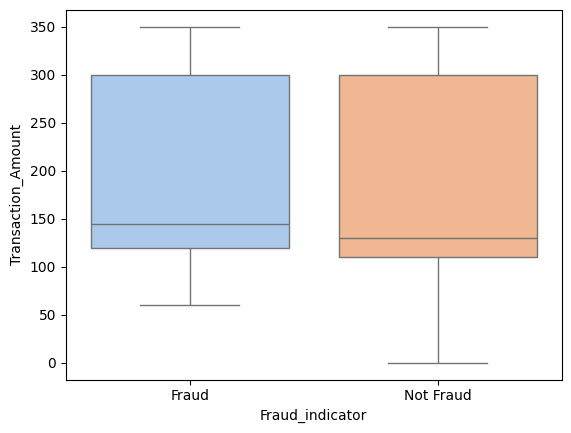

In [71]:
sns.boxplot(x='Fraud_indicator',y='Transaction_Amount',data=df,palette='pastel')
plt.show()

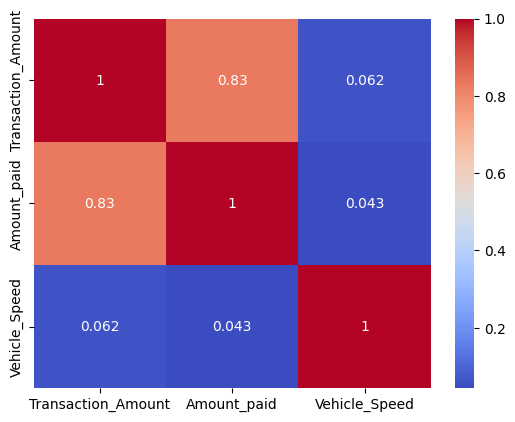

In [72]:
# Correlation matrix and heatmap for numerical variables
correlation_matrix = df[['Transaction_Amount', 'Amount_paid', 'Vehicle_Speed']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

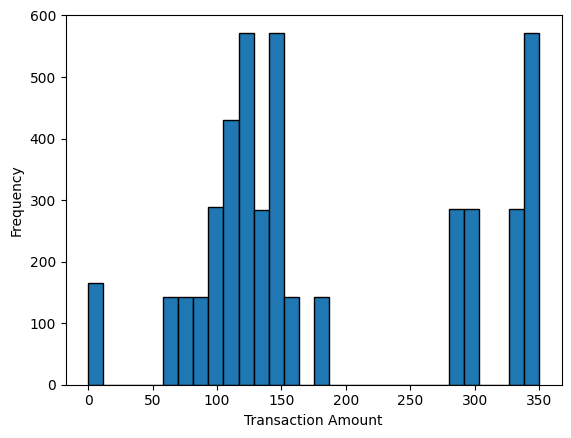

In [73]:
# Histogram of 'Transaction_Amount'
plt.hist(df['Transaction_Amount'], bins=30, edgecolor='black')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()


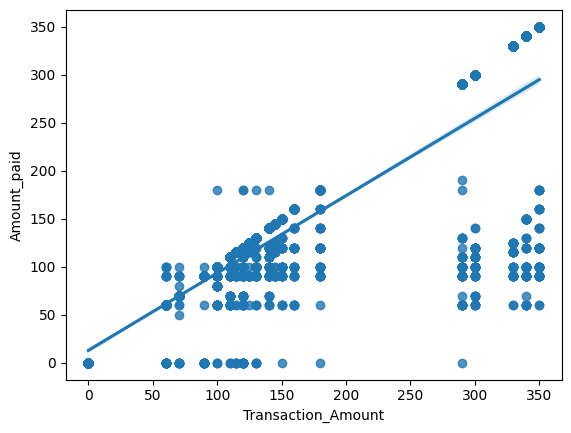

In [74]:
# Scatter plot with regression line between 'Transaction_Amount' and 'Amount_paid'
sns.regplot(x='Transaction_Amount',y='Amount_paid',data=df)
plt.show()

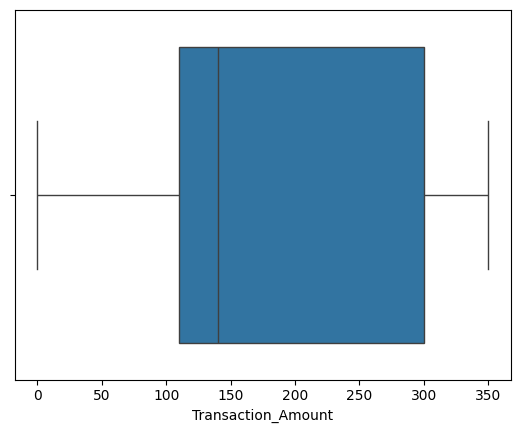

In [75]:
sns.boxplot(x='Transaction_Amount',data =df)
plt.show()

In [76]:
selected_features=['Transaction_Amount','Amount_paid']
X=df[selected_features]
y=df['Fraud_indicator']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [77]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

label_encoder=LabelEncoder()
y_train_encoded= label_encoder.fit_transform(y_train)
y_test_encoded= label_encoder.transform(y_test)

In [78]:
#Neural network model
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
model.summary()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
model.fit(X_train_scaled, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7788 - loss: 0.5268 - val_accuracy: 0.8062 - val_loss: 0.4399
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8522 - loss: 0.3545 - val_accuracy: 0.8834 - val_loss: 0.2846
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9098 - loss: 0.2234 - val_accuracy: 0.9312 - val_loss: 0.1885
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9452 - loss: 0.1566 - val_accuracy: 0.9607 - val_loss: 0.1474
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9593 - loss: 0.1219 - val_accuracy: 0.9635 - val_loss: 0.1216
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9673 - loss: 0.1014 - val_accuracy: 0.9719 - val_loss: 0.1072
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9789 - loss: 0.0884 - val_accuracy: 0.9817 - val_loss: 0.0961
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9821 - loss: 0.0748 - val_accuracy: 0.9817 - val_loss:

In [81]:
y_pred_prob=model.predict(X_test_scaled)
#Convert probabilities to binary predictiobs
y_pred=np.round(y_pred_prob)

#Print accuracy metrics
accuracy=accuracy_score(y_test_encoded,y_pred)
precision=precision_score(y_test_encoded,y_pred)
recall=recall_score(y_test_encoded,y_pred)
f1=f1_score(y_test_encoded,y_pred)

#print accuracy metrices
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("Precision: {:.2f}".format(precision))
print("Recall: {:.2f}".format(recall))
print("F1 Score: {:.2f}".format(f1))


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 98.43%
Precision: 0.98
Recall: 1.00
F1 Score: 0.99


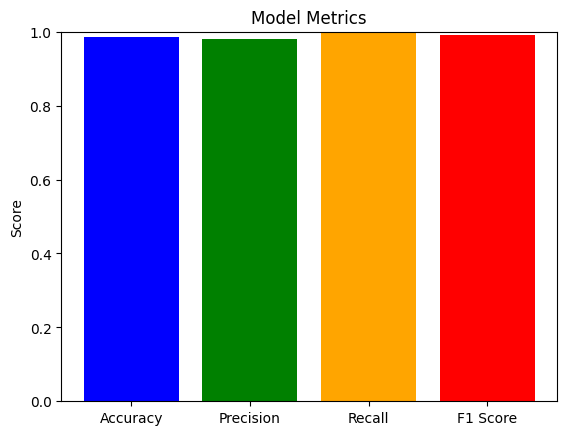

In [82]:
#Accuracy metrics
import matplotlib.pyplot as plt
metrics=['Accuracy','Precision','Recall','F1 Score']
values=[accuracy,precision,recall,f1]
plt.bar(metrics,values, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Score')
plt.title('Model Metrics')
plt.ylim(0, 1)
plt.show()

In [83]:
# save model
with open('model.pkl', 'wb') as f:
    model.save('model.keras')

In [85]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(label_encoder, open('label_encoder.pkl', 'wb'))